In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

repo_url = (
    "https://huggingface.co/datasets/"
    "CasparFermin/llm-guided-modelling-results/resolve/main"
)

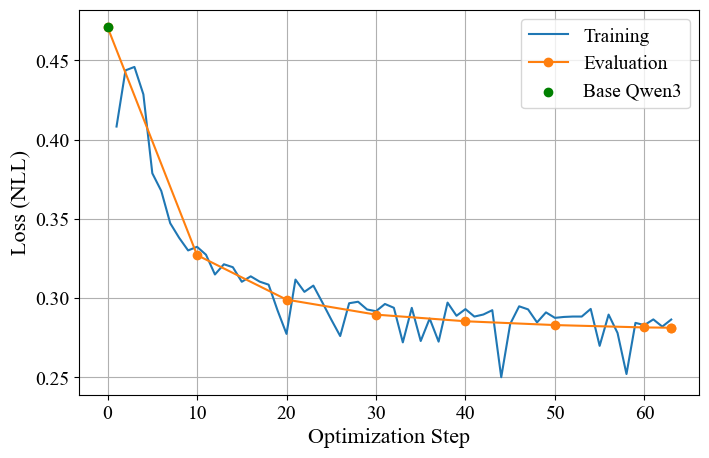

In [ ]:
# get final trainer log history
df = pd.read_csv(f"{repo_url}/FineTuning/SFTTrainer_logs.csv")
bl_df = pd.read_csv(f"{repo_url}/FineTuning/baseline_metrics.csv")
bl_df['step'] = 0

# Separate train / eval rows
train_df = df[df["loss"].notna()].copy()
eval_df  = pd.concat([bl_df, df[df["eval_loss"].notna()].copy()])

# Plot
plt.figure(figsize=(8, 5))
plt.rcParams.update({
    "font.size": 14,       # default text
    "axes.labelsize": 16,  # axis labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})
plt.plot(
    train_df["step"],
    train_df["loss"],
    label="Training"
)

plt.plot(
    eval_df["step"],
    eval_df["eval_loss"],
    label="Evaluation",
    marker='o'
)

# Highlight first point (baseline)
plt.scatter(
    eval_df["step"].iloc[0],
    eval_df["eval_loss"].iloc[0],
    color="green",
    label="Base Qwen3",
    zorder=5
)

plt.xlabel("Optimization Step")
plt.ylabel("Loss (NLL)")
plt.legend()
plt.grid(True)
plt.savefig(
    "../Images/FineTune_LossCurve.png",
    transparent=True,
    bbox_inches="tight",
    dpi=300
)
plt.show()